In [3]:
file_map = {
    "LUSC_outputs":       "FGC_GNN_LUSC_cv_results.csv",
    "ROSMAP_output_new":  "FGC_GNN_ROSMAP_cv_results.csv",
    "LAML_Output_new":    "FGC_GNN_LAML_cv_results.csv",
    "BRCA_output":        "FGC_GNN_BRCA_cv_results.csv",
}

for folder, filename in file_map.items():
    filepath = os.path.join(folder, filename)
    try:
        df = pd.read_csv(filepath, nrows=0)  # only header
        print(f"\nFolder: {folder}")
        print(f"File: {filename}")
        print(f"Columns: {df.columns.tolist()}")
    except FileNotFoundError:
        print(f"\nFile not found: {filepath}")
    except Exception as e:
        print(f"\nError reading {filepath}: {e}")


Folder: LUSC_outputs
File: FGC_GNN_LUSC_cv_results.csv
Columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc', 'mean_thr']

Folder: ROSMAP_output_new
File: FGC_GNN_ROSMAP_cv_results.csv
Columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_val_AUC', 'std_val_AUC']

Folder: LAML_Output_new
File: FGC_GNN_LAML_cv_results.csv
Columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']

Folder: BRCA_output
File: FGC_GNN_BRCA_cv_results.csv
Columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']


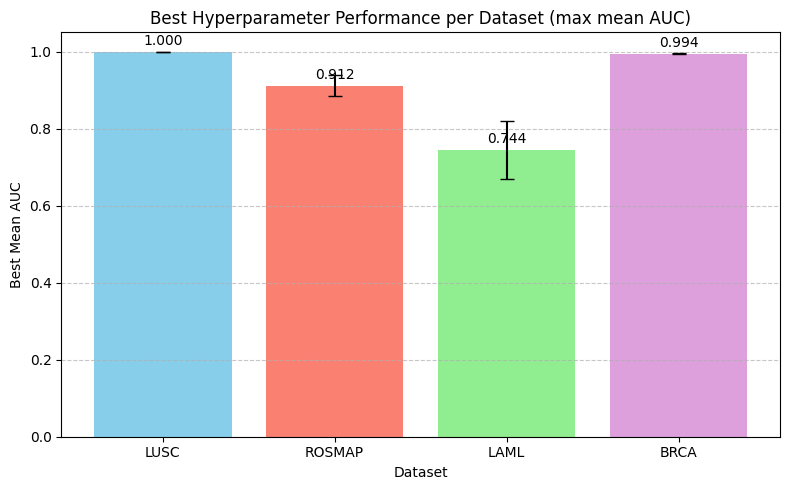

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. Read all CSVs and unify column names ---
file_map = {
    "LUSC_outputs":        "FGC_GNN_LUSC_cv_results.csv",
    "ROSMAP_output_new":   "FGC_GNN_ROSMAP_cv_results.csv",
    "LAML_Output_new":     "FGC_GNN_LAML_cv_results.csv",
    "BRCA_output":         "FGC_GNN_BRCA_cv_results.csv",
}

# Nice short names for the x-axis
dataset_names = {
    "LUSC_outputs":       "LUSC",
    "ROSMAP_output_new":  "ROSMAP",
    "LAML_Output_new":    "LAML",
    "BRCA_output":        "BRCA",
}

all_data = {}  # to store the full DataFrames if needed later

for folder, filename in file_map.items():
    path = os.path.join(folder, filename)
    df = pd.read_csv(path)
    
    # Unify AUC column name: "mean_val_AUC" -> "mean_auc"
    if "mean_val_AUC" in df.columns:
        df.rename(columns={"mean_val_AUC": "mean_auc",
                           "std_val_AUC": "std_auc"}, inplace=True)
    
    all_data[folder] = df

# --- 2. Extract best run (max mean_auc) per dataset ---
best_results = []
for folder, df in all_data.items():
    best_row = df.loc[df["mean_auc"].idxmax()]  # row with highest mean_auc
    best_results.append({
        "Dataset": dataset_names[folder],
        "Best AUC": best_row["mean_auc"],
        "Std AUC":  best_row["std_auc"] if "std_auc" in best_row else 0,
    })

best_df = pd.DataFrame(best_results)

# --- 3. Plot bar chart with error bars ---
plt.figure(figsize=(8, 5))
bars = plt.bar(best_df["Dataset"], best_df["Best AUC"],
               yerr=best_df["Std AUC"], capsize=5,
               color=['skyblue', 'salmon', 'lightgreen', 'plum'])
plt.xlabel("Dataset")
plt.ylabel("Best Mean AUC")
plt.title("Best Hyperparameter Performance per Dataset (max mean AUC)")
plt.ylim(bottom=0)  # AUC usually between 0.5 and 1, adjust if needed
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on bars
for bar, auc in zip(bars, best_df["Best AUC"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{auc:.3f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("best_auc_per_dataset.png", dpi=150)
plt.show()

In [1]:
"""
Hyperparameter Empirical Study Plots
=====================================
For each hyperparameter, produces a grouped bar chart where:
  - X-axis  : Dataset names (LUSC, ROSMAP, LAML, BRCA)
  - Y-axis  : Mean AUC (with ± std error bars)
  - Bar groups: One group per dataset, bars coloured by hyperparameter value

Usage:
    python plot_hyperparam_study.py

Expects CSV files relative to the script location (same layout as your
original code). Each CSV must contain at minimum:
    mean_auc  (or mean_val_AUC)  – float
    std_auc   (or std_val_AUC)   – float
plus whatever hyperparameter columns exist (e.g. lr, hidden_dim, …).

The script auto-detects hyperparameter columns by excluding known
metric / bookkeeping columns.
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from itertools import cycle

# ── 1. Configuration ──────────────────────────────────────────────────────────

FILE_MAP = {
    "LUSC_outputs":       "FGC_GNN_LUSC_cv_results.csv",
    "ROSMAP_output_new":  "FGC_GNN_ROSMAP_cv_results.csv",
    "LAML_Output_new":    "FGC_GNN_LAML_cv_results.csv",
    "BRCA_output":        "FGC_GNN_BRCA_cv_results.csv",
}

DATASET_LABELS = {
    "LUSC_outputs":       "LUSC",
    "ROSMAP_output_new":  "ROSMAP",
    "LAML_Output_new":    "LAML",
    "BRCA_output":        "BRCA",
}

# Columns that are NOT hyperparameters (metrics, fold info, indices, etc.)
NON_HYPERPARAM_COLS = {
    "mean_auc", "std_auc",
    "mean_val_AUC", "std_val_AUC",
    "mean_val_acc", "std_val_acc",
    "mean_val_f1",  "std_val_f1",
    "fold", "run", "index", "epoch",
    "train_auc", "val_auc",
}

OUTPUT_DIR = "hyperparam_plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── 2. Load & harmonise data ───────────────────────────────────────────────────

all_data: dict[str, pd.DataFrame] = {}

for folder, filename in FILE_MAP.items():
    path = os.path.join(folder, filename)
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"[WARN] File not found: {path}  – skipping.")
        continue

    # Normalise AUC column names
    if "mean_val_AUC" in df.columns:
        df.rename(columns={"mean_val_AUC": "mean_auc",
                            "std_val_AUC":  "std_auc"}, inplace=True)

    all_data[folder] = df
    print(f"Loaded {folder}: {len(df)} rows, columns: {df.columns.tolist()}")

if not all_data:
    raise SystemExit("No CSV files could be loaded. "
                     "Check FILE_MAP paths and re-run.")

# ── 3. Detect hyperparameter columns ─────────────────────────────────────────

# Union of all columns across datasets, minus non-hyperparameter columns
all_cols: set[str] = set()
for df in all_data.values():
    all_cols.update(df.columns)

hyperparam_cols = sorted(all_cols - NON_HYPERPARAM_COLS)
print(f"\nDetected hyperparameters: {hyperparam_cols}\n")

if not hyperparam_cols:
    raise SystemExit(
        "No hyperparameter columns detected. "
        "Add column names to NON_HYPERPARAM_COLS if they are metrics."
    )

# ── 4. Build per-hyperparameter summary ───────────────────────────────────────
# For each hyperparameter H and each unique value v of H:
#   mean_auc aggregated (mean ± std) across all rows where H == v,
#   computed per dataset.

def summarise(df: pd.DataFrame, hp_col: str) -> pd.DataFrame:
    """Return grouped mean/std by hp_col value."""
    if hp_col not in df.columns:
        return pd.DataFrame()
    grp = df.groupby(hp_col)["mean_auc"].agg(["mean", "std"]).reset_index()
    grp.columns = [hp_col, "auc_mean", "auc_std"]
    grp["auc_std"] = grp["auc_std"].fillna(0)
    return grp

# ── 5. Colour palette ─────────────────────────────────────────────────────────

PALETTE = [
    "#4C9BE8", "#E8744C", "#4CE896", "#E84C9B",
    "#9B4CE8", "#E8C84C", "#4CE8D8", "#E84C4C",
    "#8AE84C", "#4C6CE8", "#E88A4C", "#4CE87A",
]

# ── 6. Plot one figure per hyperparameter ─────────────────────────────────────

dataset_order = [k for k in FILE_MAP if k in all_data]   # preserve order
x_labels = [DATASET_LABELS[k] for k in dataset_order]
n_datasets = len(dataset_order)

for hp in hyperparam_cols:

    # Collect all unique values of this HP (union across datasets)
    hp_values: list = []
    for folder in dataset_order:
        df = all_data[folder]
        if hp in df.columns:
            for v in df[hp].dropna().unique():
                if v not in hp_values:
                    hp_values.append(v)

    # Try to sort numerically, fall back to string sort
    try:
        hp_values = sorted(hp_values, key=float)
    except (TypeError, ValueError):
        hp_values = sorted(hp_values, key=str)

    n_vals = len(hp_values)
    if n_vals == 0:
        continue

    colour_map = {v: PALETTE[i % len(PALETTE)] for i, v in enumerate(hp_values)}

    # Bar geometry
    bar_width = 0.8 / n_vals          # bars fill ~80 % of each x slot
    offsets = np.linspace(-(n_vals - 1) / 2, (n_vals - 1) / 2, n_vals) * bar_width

    fig, ax = plt.subplots(figsize=(max(8, n_datasets * 1.8 + 2), 5.5))

    x_positions = np.arange(n_datasets)

    for i, val in enumerate(hp_values):
        auc_means = []
        auc_stds  = []
        for folder in dataset_order:
            df = all_data[folder]
            if hp not in df.columns:
                auc_means.append(np.nan)
                auc_stds.append(0)
                continue
            subset = df[df[hp] == val]
            if subset.empty:
                auc_means.append(np.nan)
                auc_stds.append(0)
            else:
                auc_means.append(subset["mean_auc"].mean())
                auc_stds.append(subset["mean_auc"].std(ddof=0))

        auc_means = np.array(auc_means, dtype=float)
        auc_stds  = np.array(auc_stds,  dtype=float)
        xs = x_positions + offsets[i]

        bars = ax.bar(
            xs, auc_means,
            width=bar_width,
            yerr=np.nan_to_num(auc_stds),
            capsize=4,
            color=colour_map[val],
            edgecolor="white",
            linewidth=0.6,
            label=str(val),
            error_kw=dict(elinewidth=1.2, ecolor="#333333"),
            zorder=3,
        )

        # Value labels on top of each bar
        for bar, mean_val in zip(bars, auc_means):
            if not np.isnan(mean_val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + max(auc_stds) * 0.05 + 0.005,
                    f"{mean_val:.3f}",
                    ha="center", va="bottom",
                    fontsize=7.5, color="#222222",
                    zorder=4,
                )

    # Axes formatting
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=12, fontweight="bold")
    ax.set_ylabel("Mean AUC", fontsize=12)
    ax.set_xlabel("Dataset", fontsize=12)
    ax.set_title(
        f"Empirical Study — Hyperparameter: {hp}",
        fontsize=14, fontweight="bold", pad=14,
    )
    ax.set_ylim(bottom=max(0, np.nanmin(
        [all_data[f]["mean_auc"].min() for f in dataset_order]) - 0.05))
    ax.yaxis.grid(True, linestyle="--", alpha=0.6, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    # Legend
    legend_patches = [
        mpatches.Patch(color=colour_map[v], label=f"{hp} = {v}")
        for v in hp_values
    ]
    ax.legend(
        handles=legend_patches,
        title=hp,
        title_fontsize=10,
        fontsize=9,
        loc="upper right",
        framealpha=0.9,
        edgecolor="#cccccc",
    )

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, f"hyperparam_{hp}.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved → {save_path}")

print("\nAll plots saved to:", os.path.abspath(OUTPUT_DIR))

Loaded LUSC_outputs: 288 rows, columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc', 'mean_thr']
Loaded ROSMAP_output_new: 288 rows, columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc']
Loaded LAML_Output_new: 288 rows, columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']
Loaded BRCA_output: 288 rows, columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']

Detected hyperparameters: ['dropout', 'epochs', 'focal_alpha', 'focal_gamma', 'hidden_channels', 'lr', 'mean_acc', 'mean_f1', 'mean_thr', 'weight_decay']

Saved → hyperparam_plots\hyperparam_dropout.png
Saved → hyperparam_plots\hyperparam_epochs.png
Saved → hyperparam_plots\hyperparam_f

C:\Users\aritr\AppData\Local\Temp\ipykernel_34968\143389987.py:233: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → hyperparam_plots\hyperparam_mean_acc.png


C:\Users\aritr\AppData\Local\Temp\ipykernel_34968\143389987.py:233: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → hyperparam_plots\hyperparam_mean_f1.png


C:\Users\aritr\AppData\Local\Temp\ipykernel_34968\143389987.py:233: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved → hyperparam_plots\hyperparam_mean_thr.png
Saved → hyperparam_plots\hyperparam_weight_decay.png

All plots saved to: D:\Anushree\hyperparam_plots


In [3]:
"""
Hyperparameter Empirical Study — Single Figure with Subplots
=============================================================
One subplot per hyperparameter, all in a single saved figure.
  - X-axis        : Dataset names (LUSC, ROSMAP, LAML, BRCA)
  - Y-axis        : Mean AUC ± std error bars
  - Bars per group: One bar per hyperparameter value, each a distinct colour
  - Layout        : Auto-computed grid (≤3 columns)

Usage:
    python plot_hyperparam_study.py

CSV files must live at  <folder>/<filename>  relative to this script and
must contain at minimum:
    mean_auc  (or mean_val_AUC)   – float
    std_auc   (or std_val_AUC)    – float
plus any hyperparameter columns (lr, hidden_dim, dropout, …).

Hyperparameter columns are auto-detected by excluding known metric /
bookkeeping column names listed in NON_HYPERPARAM_COLS.
"""

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. Configuration ───────────────────────────────────────────────────────────

FILE_MAP = {
    "LUSC_outputs":       "FGC_GNN_LUSC_cv_results.csv",
    "ROSMAP_output_new":  "FGC_GNN_ROSMAP_cv_results.csv",
    "LAML_Output_new":    "FGC_GNN_LAML_cv_results.csv",
    "BRCA_output":        "FGC_GNN_BRCA_cv_results.csv",
}

DATASET_LABELS = {
    "LUSC_outputs":       "LUSC",
    "ROSMAP_output_new":  "ROSMAP",
    "LAML_Output_new":    "LAML",
    "BRCA_output":        "BRCA",
}

NON_HYPERPARAM_COLS = {
    "mean_auc", "std_auc",
    "mean_val_AUC", "std_val_AUC",
    "mean_val_acc", "std_val_acc",
    "mean_val_f1",  "std_val_f1",
    "fold", "run", "index", "epoch",
    "train_auc", "val_auc",
}

PALETTE = [
    "#4C9BE8", "#E8744C", "#4CE896", "#E84C9B",
    "#9B4CE8", "#E8C84C", "#4CE8D8", "#E84C4C",
    "#8AE84C", "#4C6CE8", "#E88A4C", "#4CE87A",
]

OUTPUT_PATH = "hyperparam_study_subplots.png"
MAX_COLS    = 3          # maximum subplot columns in the grid

# ── 2. Load & harmonise data ───────────────────────────────────────────────────

all_data: dict[str, pd.DataFrame] = {}

for folder, filename in FILE_MAP.items():
    path = os.path.join(folder, filename)
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"[WARN] File not found: {path}  — skipping.")
        continue

    if "mean_val_AUC" in df.columns:
        df.rename(columns={"mean_val_AUC": "mean_auc",
                            "std_val_AUC":  "std_auc"}, inplace=True)

    all_data[folder] = df
    print(f"Loaded  {folder}:  {len(df)} rows | columns: {df.columns.tolist()}")

if not all_data:
    raise SystemExit("No CSV files loaded — check FILE_MAP paths and re-run.")

# ── 3. Auto-detect hyperparameter columns ─────────────────────────────────────

all_cols: set[str] = set()
for df in all_data.values():
    all_cols.update(df.columns)

hyperparam_cols = sorted(all_cols - NON_HYPERPARAM_COLS)
print(f"\nDetected hyperparameters: {hyperparam_cols}\n")

if not hyperparam_cols:
    raise SystemExit(
        "No hyperparameter columns detected. "
        "Add metric column names to NON_HYPERPARAM_COLS if needed."
    )

# ── 4. Layout: compute grid dimensions ────────────────────────────────────────

n_hp   = len(hyperparam_cols)
n_cols = min(n_hp, MAX_COLS)
n_rows = math.ceil(n_hp / n_cols)

dataset_order = [k for k in FILE_MAP if k in all_data]
x_labels      = [DATASET_LABELS[k] for k in dataset_order]
n_datasets    = len(dataset_order)

# Global AUC floor for consistent y-axis across subplots
global_auc_min = min(all_data[f]["mean_auc"].min() for f in dataset_order)
y_floor = max(0.0, global_auc_min - 0.05)

# ── 5. Build the figure ────────────────────────────────────────────────────────

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * max(5, n_datasets * 1.4), n_rows * 4.8),
    squeeze=False,
)

fig.suptitle(
    "Empirical Hyperparameter Study — Mean AUC per Dataset",
    fontsize=16, fontweight="bold", y=1.01,
)

x_positions = np.arange(n_datasets)

for idx, hp in enumerate(hyperparam_cols):
    row, col = divmod(idx, n_cols)
    ax = axes[row][col]

    # collect unique HP values (union across datasets, sorted)
    hp_values: list = []
    for folder in dataset_order:
        df = all_data[folder]
        if hp in df.columns:
            for v in df[hp].dropna().unique():
                if v not in hp_values:
                    hp_values.append(v)

    try:
        hp_values = sorted(hp_values, key=float)
    except (TypeError, ValueError):
        hp_values = sorted(hp_values, key=str)

    n_vals = len(hp_values)
    if n_vals == 0:
        ax.set_visible(False)
        continue

    colour_map = {v: PALETTE[i % len(PALETTE)] for i, v in enumerate(hp_values)}
    bar_width  = 0.8 / n_vals
    offsets    = (
        np.linspace(-(n_vals - 1) / 2, (n_vals - 1) / 2, n_vals) * bar_width
    )

    # draw one set of bars per HP value
    for i, val in enumerate(hp_values):
        auc_means, auc_stds = [], []
        for folder in dataset_order:
            df = all_data[folder]
            if hp not in df.columns:
                auc_means.append(np.nan)
                auc_stds.append(0.0)
                continue
            subset = df[df[hp] == val]
            if subset.empty:
                auc_means.append(np.nan)
                auc_stds.append(0.0)
            else:
                auc_means.append(subset["mean_auc"].mean())
                auc_stds.append(subset["mean_auc"].std(ddof=0))

        auc_means = np.array(auc_means, dtype=float)
        auc_stds  = np.array(auc_stds,  dtype=float)
        xs        = x_positions + offsets[i]
        std_max   = float(np.nanmax(auc_stds)) if len(auc_stds) else 0

        bars = ax.bar(
            xs, auc_means,
            width=bar_width,
            yerr=np.nan_to_num(auc_stds),
            capsize=4,
            color=colour_map[val],
            edgecolor="white",
            linewidth=0.5,
            error_kw=dict(elinewidth=1.1, ecolor="#333333"),
            zorder=3,
        )

        # value labels above each bar
        for bar, mean_val in zip(bars, auc_means):
            if not np.isnan(mean_val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + std_max * 0.05 + 0.004,
                    f"{mean_val:.3f}",
                    ha="center", va="bottom",
                    fontsize=6.5, color="#111111",
                    zorder=4,
                )

    # axes styling
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean AUC", fontsize=9)
    ax.set_xlabel("Dataset",   fontsize=9)
    ax.set_title(f"HP: {hp}", fontsize=11, fontweight="bold", pad=8)
    ax.set_ylim(bottom=y_floor)
    ax.yaxis.grid(True, linestyle="--", alpha=0.55, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="both", labelsize=8)

    # per-subplot legend
    legend_patches = [
        mpatches.Patch(color=colour_map[v], label=str(v))
        for v in hp_values
    ]
    ax.legend(
        handles=legend_patches,
        title=hp,
        title_fontsize=8,
        fontsize=7.5,
        loc="lower right",
        framealpha=0.88,
        edgecolor="#cccccc",
        ncol=1 if n_vals <= 6 else 2,
    )

# hide any leftover empty subplot cells
for idx in range(n_hp, n_rows * n_cols):
    row, col = divmod(idx, n_cols)
    axes[row][col].set_visible(False)

# ── 6. Save ────────────────────────────────────────────────────────────────────

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=150, bbox_inches="tight")
plt.close()
print(f"\nSaved → {os.path.abspath(OUTPUT_PATH)}")

Loaded  LUSC_outputs:  288 rows | columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc', 'mean_thr']
Loaded  ROSMAP_output_new:  288 rows | columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc']
Loaded  LAML_Output_new:  288 rows | columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']
Loaded  BRCA_output:  288 rows | columns: ['hidden_channels', 'lr', 'weight_decay', 'dropout', 'focal_gamma', 'focal_alpha', 'epochs', 'mean_auc', 'std_auc', 'mean_f1', 'mean_acc']

Detected hyperparameters: ['dropout', 'epochs', 'focal_alpha', 'focal_gamma', 'hidden_channels', 'lr', 'mean_acc', 'mean_f1', 'mean_thr', 'weight_decay']



C:\Users\aritr\AppData\Local\Temp\ipykernel_34968\1029308794.py:240: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()



Saved → D:\Anushree\hyperparam_study_subplots.png


In [6]:
"""
Training Loss Curves — Bold, High-Contrast Single Plot
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

FILE_MAP = {
    "LUSC_outputs":       "FGC_GNN_LUSC_epoch_metrics.csv",
    "ROSMAP_output_new":  "FGC_GNN_ROSMAP_epoch_metrics.csv",
    "LAML_Output_new":    "FGC_GNN_LAML_final_training_curve.csv",
    "BRCA_output":        "FGC_GNN_BRCA_final_training_curve.csv",
}

DATASET_LABELS = {
    "LUSC_outputs":       "LUSC",
    "ROSMAP_output_new":  "ROSMAP",
    "LAML_Output_new":    "LAML",
    "BRCA_output":        "BRCA",
}

STYLES = {
    "LUSC_outputs":      {"color": "#E63946", "linestyle": "-",  "marker": "o"},
    "ROSMAP_output_new": {"color": "#2196F3", "linestyle": "--", "marker": "s"},
    "LAML_Output_new":   {"color": "#FF9800", "linestyle": "-.", "marker": "^"},
    "BRCA_output":       {"color": "#4CAF50", "linestyle": ":",  "marker": "D"},
}

OUTPUT_PATH = "loss_curves.png"

# ── Load ───────────────────────────────────────────────────────────────────────

all_data = {}
for folder, filename in FILE_MAP.items():
    path = os.path.join(folder, filename)
    try:
        df = pd.read_csv(path)
    except FileNotFoundError:
        print(f"[WARN] Not found: {path}"); continue

    lower = {c.lower(): c for c in df.columns}
    epoch_col = lower.get("epoch")
    loss_col  = lower.get("loss") or lower.get("train_loss") or lower.get("val_loss")
    if not epoch_col or not loss_col:
        print(f"[WARN] {folder}: columns not found {df.columns.tolist()}"); continue

    df = df[[epoch_col, loss_col]].rename(columns={epoch_col: "Epoch", loss_col: "Loss"})
    df = df.dropna()
    df["Epoch"] = df["Epoch"].astype(int)
    df["Loss"]  = df["Loss"].astype(float)
    df.sort_values("Epoch", inplace=True)
    all_data[folder] = df

if not all_data:
    raise SystemExit("No data loaded.")

# ── Plot ───────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   16,
    "axes.labelsize":   13,
    "xtick.labelsize":  11,
    "ytick.labelsize":  11,
    "legend.fontsize":  11,
})

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#F7F9FC")

for folder, df in all_data.items():
    s   = STYLES[folder]
    lbl = DATASET_LABELS[folder]

    # thick line, every Nth point gets a marker so they don't crowd
    n     = max(1, len(df) // 20)
    every = slice(None, None, n)

    ax.plot(
        df["Epoch"], df["Loss"],
        color=s["color"], linestyle=s["linestyle"],
        linewidth=3, label=lbl, zorder=3, alpha=0.95,
    )
    ax.plot(
        df["Epoch"].iloc[every], df["Loss"].iloc[every],
        color=s["color"], linestyle="none",
        marker=s["marker"], markersize=8,
        markerfacecolor="white", markeredgecolor=s["color"],
        markeredgewidth=2.2, zorder=4,
    )

# Grid
ax.yaxis.grid(True, linestyle="--", linewidth=0.8, color="#CCCCCC", zorder=0)
ax.xaxis.grid(True, linestyle=":",  linewidth=0.6, color="#DDDDDD", zorder=0)
ax.set_axisbelow(True)

# Spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.4)
    ax.spines[spine].set_color("#AAAAAA")

# Labels & title
ax.set_title("Training Loss Curves", fontsize=17, fontweight="bold",
             pad=14, color="#111111")
ax.set_xlabel("Epoch", fontsize=13, labelpad=8)
ax.set_ylabel("Loss",  fontsize=13, labelpad=8)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=10))
ax.tick_params(axis="both", which="both", length=0)

# Bold legend with border
leg = ax.legend(
    title="Dataset", title_fontsize=12,
    fontsize=11, framealpha=1,
    edgecolor="#AAAAAA", fancybox=False,
    loc="upper right",
    borderpad=0.8, labelspacing=0.6,
)
leg.get_title().set_fontweight("bold")
for line in leg.get_lines():
    line.set_linewidth(3.5)

plt.tight_layout()
plt.savefig(OUTPUT_PATH, dpi=180, bbox_inches="tight")
plt.close()
print(f"Saved → {os.path.abspath(OUTPUT_PATH)}")

Saved → D:\Anushree\loss_curves.png
